# Workshop 1  
# From Raw Data to Insight: End-to-End Workflow

**Case Study:** Digital Inequity in New Jersey  
**Duration:** 2 hours  
**Format:** Guided hands-on lab  

## Learning Objectives
By the end of this notebook, participants will be able to:

1. Load and inspect a real-world-style dataset.
2. Identify common data quality issues: missing values, outliers, duplicates, and special placeholder codes.
3. Clean a dataset in a transparent and reproducible way.
4. Conduct exploratory data analysis (EDA).
5. Create simple visualizations.
6. Translate patterns into plain-language insights.

## Workshop Framing

In applied data science, the goal is not simply to run code. The goal is to answer a meaningful question using evidence.

For this case study, we are asking:

> **What factors are associated with differences in internet access across New Jersey communities?**

This version of the notebook intentionally uses a **messy synthetic teaching dataset**. It includes the kinds of problems analysts often encounter in real public datasets:

- Missing values
- Outliers
- Duplicate records
- Special placeholder codes such as `666666`, `999`, and `-999`

The workflow is:

**Problem → Data Inspection → Data Quality Checks → Cleaning → Exploration → Visualization → Insight**

## Key Python Libraries Used

### `pandas`
Used for working with tabular data. In this workshop, `pandas` helps us load CSV files, inspect columns, identify missing values, clean special codes, group data, and summarize variables.

### `numpy`
Used for numerical operations. Here, `numpy` helps us work with missing values using `np.nan` and perform numerical calculations.

### `matplotlib.pyplot`
Used for creating basic charts. It gives us direct control over figure size, titles, labels, and visual output.

### `seaborn`
Used for statistical visualizations. It builds on Matplotlib and makes it easier to create histograms, scatterplots, boxplots, and regression-style visuals.

### `google.colab.files`
Used only in Google Colab to upload files from your computer into the notebook environment.

In [1]:
# ============================================================
# SETUP
# ============================================================
# This notebook is designed for Google Colab.
# If you have a teaching CSV, upload it when prompted.
# Recommended file name: digital_inequity_nj_messy_synthetic.csv
# If no file is uploaded, the notebook will generate a messy synthetic dataset.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visual style — consistent with workshop materials
sns.set_theme(style="whitegrid")
PALETTE = ["#2A3F7E", "#C9A84C", "#CADCFC", "#1E2761", "#F0D080"]
sns.set_palette(PALETTE)
plt.rcParams["figure.dpi"] = 110

print("Setup complete.")

Setup complete.


## 1. Load the Dataset

There are two ways to use this notebook:

1. **Upload the provided messy teaching dataset** in Colab.
2. **Use the built-in synthetic dataset generator** if no file is uploaded.

The dataset is synthetic, but it is designed to resemble a public data workflow where variables may be incomplete, coded inconsistently, or contain unusual values.

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

DATA_FILE = "digital_inequity_nj_messy_synthetic.csv"

try:
    from google.colab import files
    print("Upload your CSV file if you have it. You may cancel upload to use generated demo data.")
    uploaded = files.upload()
    if len(uploaded) > 0:
        DATA_FILE = list(uploaded.keys())[0]
except Exception:
    print("Not running in Colab or upload skipped. Looking for a local CSV file.")

def generate_messy_demo_data(n=140, seed=123):
    rng = np.random.default_rng(seed)
    counties = [
        "Bergen", "Essex", "Hudson", "Middlesex", "Monmouth", "Morris",
        "Passaic", "Union", "Camden", "Mercer", "Ocean", "Burlington"
    ]

    county = rng.choice(counties, size=n)
    tract_id = [f"NJ-{i:03d}" for i in range(1, n + 1)]
    median_income = rng.normal(78000, 23000, n).clip(25000, 165000)
    bachelor_degree_rate = rng.normal(38, 14, n).clip(5, 78)
    poverty_rate = rng.normal(12, 6, n).clip(1, 35)
    unemployment_rate = rng.normal(6, 2, n).clip(1, 16)

    internet_access_rate = (
        58
        + (median_income - 50000) / 3000
        + bachelor_degree_rate * 0.25
        - poverty_rate * 0.40
        + rng.normal(0, 5, n)
    )
    internet_access_rate = np.clip(internet_access_rate, 35, 99)

    broadband_subscription_rate = np.clip(
        internet_access_rate - rng.normal(3, 4, n),
        25,
        99
    )

    data = pd.DataFrame({
        "tract_id": tract_id,
        "county": county,
        "median_income": np.round(median_income, 0),
        "internet_access_rate": np.round(internet_access_rate, 1),
        "broadband_subscription_rate": np.round(broadband_subscription_rate, 1),
        "bachelor_degree_rate": np.round(bachelor_degree_rate, 1),
        "poverty_rate": np.round(poverty_rate, 1),
        "unemployment_rate": np.round(unemployment_rate, 1),
    })

    # Inject missing values
    for col, k in [("median_income", 6), ("internet_access_rate", 5),
                   ("bachelor_degree_rate", 4), ("poverty_rate", 4)]:
        idx = rng.choice(data.index, size=k, replace=False)
        data.loc[idx, col] = np.nan

    # Inject special placeholder codes
    data.loc[rng.choice(data.index, size=5, replace=False), "median_income"] = 666666
    data.loc[rng.choice(data.index, size=3, replace=False), "internet_access_rate"] = 999
    data.loc[rng.choice(data.index, size=3, replace=False), "bachelor_degree_rate"] = -999
    data.loc[rng.choice(data.index, size=2, replace=False), "poverty_rate"] = 666666

    # Inject outliers and impossible values
    data.loc[rng.choice(data.index, size=2, replace=False), "median_income"] = [350000, 5000]
    data.loc[rng.choice(data.index, size=2, replace=False), "internet_access_rate"] = [130, -5]
    data.loc[rng.choice(data.index, size=2, replace=False), "broadband_subscription_rate"] = [122, -10]

    # Add one duplicate row
    data = pd.concat([data, data.iloc[[0]]], ignore_index=True)
    return data

if os.path.exists(DATA_FILE):
    raw_data = pd.read_csv(DATA_FILE)
    print(f"Loaded file: {DATA_FILE}")
else:
    raw_data = generate_messy_demo_data()
    print("No CSV found. Generated messy synthetic demo data.")

raw_data.head()

Upload your CSV file if you have it. You may cancel upload to use generated demo data.


Saving digital_inequity_nj_messy_synthetic.csv to digital_inequity_nj_messy_synthetic.csv
Loaded file: digital_inequity_nj_messy_synthetic.csv


,tract_id,county,median_income,internet_access_rate,broadband_subscription_rate,bachelor_degree_rate,poverty_rate,unemployment_rate
0,NJ-001,Bergen,"84,835.00",71.20,65.30,5.30,7.60,8.50
1,NJ-002,Camden,"67,915.00",75.00,66.00,53.80,13.90,4.20
2,NJ-003,Union,"73,132.00",76.80,73.10,74.80,13.80,4.60
3,NJ-004,Bergen,"86,371.00",81.10,78.00,44.30,19.10,3.40
4,NJ-005,Ocean,"99,918.00",75.00,70.40,41.30,20.20,9.70


## 2. Initial Dataset Inspection

Before cleaning anything, inspect the dataset exactly as received. This protects the integrity of the workflow because you can document what was changed and why.

Look for:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Suspicious minimum or maximum values
- Duplicate records

In [ ]:
print("Rows and columns:", raw_data.shape)

print("\nColumns:")
print(raw_data.columns.tolist())

Rows and columns: (141, 8)

Columns:
['tract_id', 'county', 'median_income', 'internet_access_rate', 'broadband_subscription_rate', 'bachelor_degree_rate', 'poverty_rate', 'unemployment_rate']


In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tract_id                     141 non-null    object 
 1   county                       141 non-null    object 
 2   median_income                135 non-null    float64
 3   internet_access_rate         136 non-null    float64
 4   broadband_subscription_rate  141 non-null    float64
 5   bachelor_degree_rate         137 non-null    float64
 6   poverty_rate                 137 non-null    float64
 7   unemployment_rate            141 non-null    float64
dtypes: float64(6), object(2)
memory usage: 8.9+ KB


In [ ]:
raw_data.head(10)

,tract_id,county,median_income,internet_access_rate,broadband_subscription_rate,bachelor_degree_rate,poverty_rate,unemployment_rate
0,NJ-001,Bergen,"84,835.00",71.20,65.30,5.30,7.60,8.50
1,NJ-002,Camden,"67,915.00",75.00,66.00,53.80,13.90,4.20
2,NJ-003,Union,"73,132.00",76.80,73.10,74.80,13.80,4.60
3,NJ-004,Bergen,"86,371.00",81.10,78.00,44.30,19.10,3.40
4,NJ-005,Ocean,"99,918.00",75.00,70.40,41.30,20.20,9.70
5,NJ-006,Hudson,"112,949.00",84.30,81.00,47.80,23.30,5.00
6,NJ-007,Middlesex,"117,190.00",90.90,90.80,48.20,13.80,5.90
7,NJ-008,Hudson,"72,276.00",68.80,65.60,39.90,14.50,5.00
8,NJ-009,Monmouth,"66,506.00",73.40,65.30,32.80,8.60,6.30
9,NJ-010,Hudson,"80,291.00",74.00,70.50,43.10,7.40,3.90


## 3. Missing Data Check

Missing data means values are absent. In `pandas`, missing values usually appear as `NaN`.

Missing data matters because:

- It can bias results.
- Some models cannot run with missing values.
- Missingness may itself reveal a data collection problem.

In this workshop, we will count missing values by column and then decide how to handle them.

In [ ]:
missing_summary = (
    raw_data.isna().sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: (x["missing_count"] / len(raw_data) * 100).round(2))
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_percent
median_income,6,4.26
internet_access_rate,5,3.55
poverty_rate,4,2.84
bachelor_degree_rate,4,2.84
tract_id,0,0.00
county,0,0.00
broadband_subscription_rate,0,0.00
unemployment_rate,0,0.00


## 4. Special Placeholder Codes

Many public datasets use numeric codes to represent missing, suppressed, unavailable, or invalid values.

Examples in this teaching dataset include:

- `666666` = placeholder/suppressed/unusable value
- `999` = placeholder for missing or invalid percentage/rate
- `-999` = placeholder for unavailable value

These values are dangerous because Python treats them as real numbers unless we explicitly recode them.

In [ ]:
SPECIAL_CODES = [666666, 999, -999]

for col in raw_data.select_dtypes(include="number").columns:
    counts = raw_data[col].isin(SPECIAL_CODES).sum()
    if counts > 0:
        print(f"{col}: {counts} special code value(s)")

median_income: 5 special code value(s)
internet_access_rate: 3 special code value(s)
bachelor_degree_rate: 3 special code value(s)
poverty_rate: 2 special code value(s)


In [ ]:
# Create a working copy so the raw data remains unchanged.
clean_data = raw_data.copy()

# Replace special codes with np.nan so pandas treats them as missing.
numeric_cols = clean_data.select_dtypes(include="number").columns
clean_data[numeric_cols] = clean_data[numeric_cols].replace(SPECIAL_CODES, np.nan)

print("Special codes replaced with NaN.")
clean_data.isna().sum().sort_values(ascending=False)

Special codes replaced with NaN.


,0
median_income,11
internet_access_rate,8
bachelor_degree_rate,7
poverty_rate,6
tract_id,0
county,0
broadband_subscription_rate,0
unemployment_rate,0


## 5. Duplicate Records

Duplicate rows can occur when data are merged, downloaded multiple times, or appended incorrectly.

Duplicates matter because they can overrepresent certain records and distort summaries, charts, and models.

In [ ]:
duplicate_count = clean_data.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(clean_data[clean_data.duplicated(keep=False)].sort_values(list(clean_data.columns)))

Number of duplicate rows: 1


,tract_id,county,median_income,internet_access_rate,broadband_subscription_rate,bachelor_degree_rate,poverty_rate,unemployment_rate
0,NJ-001,Bergen,"84,835.00",71.20,65.30,5.30,7.60,8.50
140,NJ-001,Bergen,"84,835.00",71.20,65.30,5.30,7.60,8.50


In [ ]:
clean_data = clean_data.drop_duplicates().reset_index(drop=True)
print("Rows after dropping duplicates:", clean_data.shape[0])

Rows after dropping duplicates: 140


## 6. Outlier and Impossible Value Checks

An outlier is a value that is unusually high or low compared with the rest of the data.

Some outliers are valid and important. Others are data errors.

For this dataset, we will apply basic validity rules:

- Percent/rate fields should generally be between `0` and `100`.
- Median household income should be positive and within a reasonable teaching range.

For this session, we will treat impossible or extreme teaching values as missing.

In [ ]:
# Check descriptive statistics after replacing special codes but before outlier treatment.
clean_data.describe()

,median_income,internet_access_rate,broadband_subscription_rate,bachelor_degree_rate,poverty_rate,unemployment_rate
count,129.00,132.00,140.00,133.00,134.00,140.00
mean,"82,372.37",72.82,69.31,37.38,11.73,6.04
std,"31,931.98",12.93,13.14,14.88,5.87,2.11
min,"5,000.00",-5.00,-10.00,5.00,1.00,1.00
25%,"69,241.00",67.90,63.00,27.90,7.43,4.70
50%,"80,305.00",72.75,69.20,39.60,11.55,6.10
75%,"96,511.00",79.00,76.85,47.80,15.47,7.72
max,"350,000.00",130.00,122.00,74.80,27.60,10.80


In [ ]:
rate_cols = [
    "internet_access_rate",
    "broadband_subscription_rate",
    "bachelor_degree_rate",
    "poverty_rate",
    "unemployment_rate"
]

for col in rate_cols:
    if col in clean_data.columns:
        invalid_mask = (clean_data[col] < 0) | (clean_data[col] > 100)
        print(f"{col}: {invalid_mask.sum()} invalid value(s) outside 0–100")
        clean_data.loc[invalid_mask, col] = np.nan

# Income reasonableness check for this teaching dataset.
if "median_income" in clean_data.columns:
    income_invalid = (clean_data["median_income"] < 15000) | (clean_data["median_income"] > 250000)
    print(f"median_income: {income_invalid.sum()} extreme or invalid value(s)")
    clean_data.loc[income_invalid, "median_income"] = np.nan

print("Validity checks complete.")

internet_access_rate: 2 invalid value(s) outside 0–100
broadband_subscription_rate: 2 invalid value(s) outside 0–100
bachelor_degree_rate: 0 invalid value(s) outside 0–100
poverty_rate: 0 invalid value(s) outside 0–100
unemployment_rate: 0 invalid value(s) outside 0–100
median_income: 2 extreme or invalid value(s)
Validity checks complete.


## 7. Decide How to Handle Missing Values

There are several common options:

1. **Drop rows** with missing values — simple, but loses data.
2. **Impute with the mean** — fills gaps with the average, but the mean is pulled by extreme values.
3. **Impute with the median** — fills gaps with the middle value; more robust when outliers are present.
4. **Keep missing values** — only if the next step can handle them natively.

For this workshop, we use the **median** because our dataset contains outliers and unusual values. The mean would be distorted by those extremes; the median is not.

We also add **missingness flags** — new binary columns that record which rows were originally incomplete. This preserves the information about data quality even after we fill the gaps.

This is not always the right method, but it is transparent and easy to explain.

In [ ]:
analysis_cols = [
    "median_income",
    "internet_access_rate",
    "broadband_subscription_rate",
    "bachelor_degree_rate",
    "poverty_rate",
    "unemployment_rate"
]

for col in analysis_cols:
    if col in clean_data.columns:
        clean_data[f"{col}_was_missing"] = clean_data[col].isna().astype(int)
        median_value = clean_data[col].median()
        clean_data[col] = clean_data[col].fillna(median_value)
        print(f"Filled missing {col} values with median: {median_value:,.2f}")

print("\nRemaining missing values:")
print(clean_data.isna().sum().sort_values(ascending=False).head(10))

Filled missing median_income values with median: 80,305.00
Filled missing internet_access_rate values with median: 72.75
Filled missing broadband_subscription_rate values with median: 69.20
Filled missing bachelor_degree_rate values with median: 39.60
Filled missing poverty_rate values with median: 11.55
Filled missing unemployment_rate values with median: 6.10

Remaining missing values:
tract_id                            0
county                              0
median_income                       0
internet_access_rate                0
broadband_subscription_rate         0
bachelor_degree_rate                0
poverty_rate                        0
unemployment_rate                   0
median_income_was_missing           0
internet_access_rate_was_missing    0
dtype: int64


## 8. Compare Raw vs Cleaned Data

A good analyst documents how the data changed during cleaning.

Here, compare the shape and summary statistics before and after cleaning.

In [ ]:
print("Raw data shape:", raw_data.shape)
print("Clean data shape:", clean_data.shape)

comparison = pd.DataFrame({
    "raw_missing": raw_data.isna().sum(),
    "clean_missing": clean_data.isna().sum()
}).fillna(0).astype(int)

comparison.head(20)

Raw data shape: (141, 8)
Clean data shape: (140, 14)


,raw_missing,clean_missing
bachelor_degree_rate,4,0
bachelor_degree_rate_was_missing,0,0
broadband_subscription_rate,0,0
broadband_subscription_rate_was_missing,0,0
county,0,0
internet_access_rate,5,0
internet_access_rate_was_missing,0,0
median_income,6,0
median_income_was_missing,0,0
poverty_rate,4,0


In [ ]:
clean_data[analysis_cols].describe()

,median_income,internet_access_rate,broadband_subscription_rate,bachelor_degree_rate,poverty_rate,unemployment_rate
count,140.00,140.00,140.00,140.00,140.00,140.00
mean,"80,821.44",72.96,69.49,37.49,11.72,6.04
std,"19,457.22",9.51,10.36,14.51,5.74,2.11
min,"25,000.00",42.10,41.20,5.00,1.00,1.00
25%,"69,793.50",68.15,63.22,28.58,7.57,4.70
50%,"80,305.00",72.75,69.20,39.60,11.55,6.10
75%,"92,811.25",78.12,76.35,46.65,15.33,7.72
max,"130,107.00",94.40,98.50,74.80,27.60,10.80


## 9. Ask Initial Analytical Questions

Now that the data has been cleaned, we can begin exploratory analysis.

Example questions:

1. Which communities have lower internet access rates?
2. Is income associated with internet access?
3. Do education or poverty indicators appear related to digital access?
4. What additional variables would strengthen this analysis?

In [ ]:
# ============================================================
# YOUR TURN — explore the questions above
# ============================================================
# Try one or more of the example queries below, or write your own.

# Which communities have the lowest internet access rates?
clean_data.nsmallest(10, "internet_access_rate")[["tract_id", "county", "internet_access_rate", "median_income"]]

,tract_id,county,internet_access_rate,median_income
92,NJ-093,Morris,42.10,"33,580.00"
43,NJ-044,Essex,45.10,"39,227.00"
131,NJ-132,Bergen,47.30,"39,855.00"
45,NJ-046,Morris,49.70,"25,000.00"
84,NJ-085,Burlington,56.10,"80,305.00"
17,NJ-018,Mercer,56.70,"71,482.00"
117,NJ-118,Middlesex,57.00,"59,609.00"
36,NJ-037,Ocean,57.30,"71,532.00"
49,NJ-050,Hudson,57.80,"80,305.00"
53,NJ-054,Morris,59.60,"72,116.00"


#Add your insights here:


## 10. Explore Key Variables

We will start by examining the distribution of internet access rates.

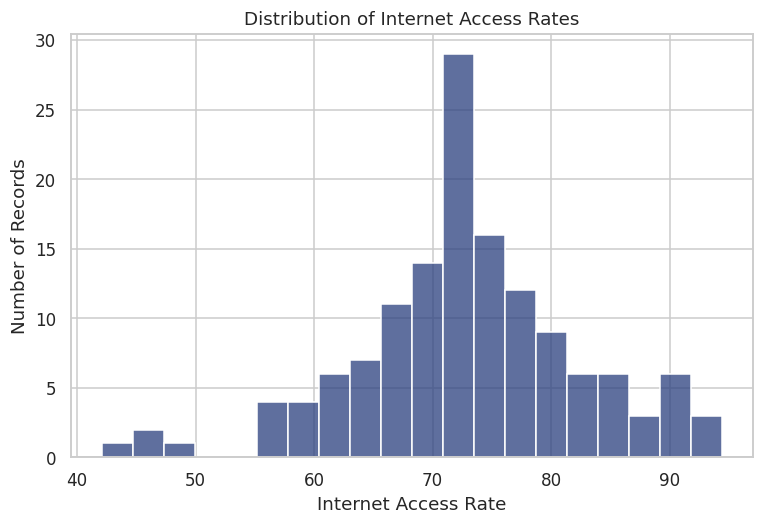

In [ ]:
plt.figure(figsize=(8, 5))

if HAS_SEABORN:
    sns.histplot(data=clean_data, x="internet_access_rate", bins=20)
else:
    plt.hist(clean_data["internet_access_rate"].dropna(), bins=20)

plt.title("Distribution of Internet Access Rates")
plt.xlabel("Internet Access Rate")
plt.ylabel("Number of Records")
plt.show()

### Reflection Prompt

Write 1–2 sentences:

- Are most communities clustered around similar internet access rates?
- Are there any low-access or high-access outliers after cleaning?

In [ ]:
# Student notes:
# Observation about distribution:


## 11. Explore Relationships

Next, we examine whether median income appears related to internet access.

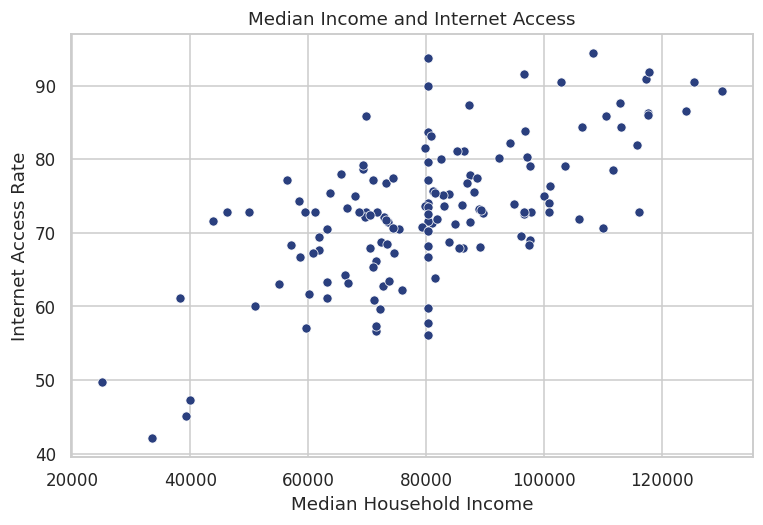

In [ ]:
plt.figure(figsize=(8, 5))

if HAS_SEABORN:
    sns.scatterplot(data=clean_data, x="median_income", y="internet_access_rate")
else:
    plt.scatter(clean_data["median_income"], clean_data["internet_access_rate"])

plt.title("Median Income and Internet Access")
plt.xlabel("Median Household Income")
plt.ylabel("Internet Access Rate")
plt.show()

### Reflection Prompt

Write 1–2 sentences:

- Does the relationship appear positive, negative, or unclear?
- What might explain this pattern?

In [ ]:
# Student notes:
# Relationship between median income and internet access:


## 12. Use Boxplots to Spot Remaining Outliers

Boxplots are useful for identifying unusual values after cleaning. They do not prove that a value is wrong, but they help us decide what needs closer review.

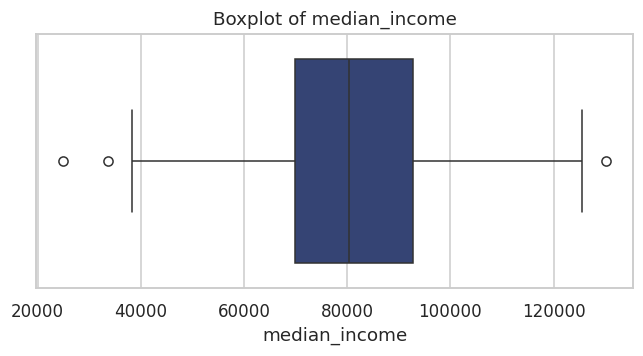

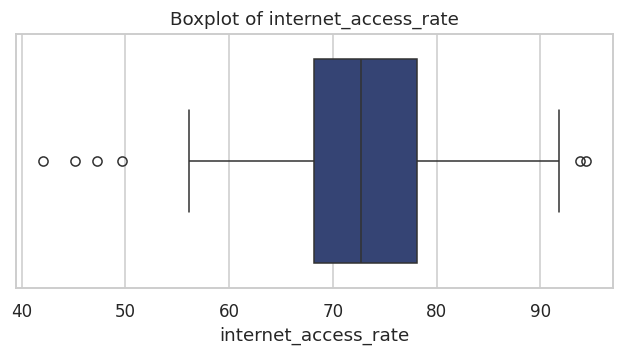

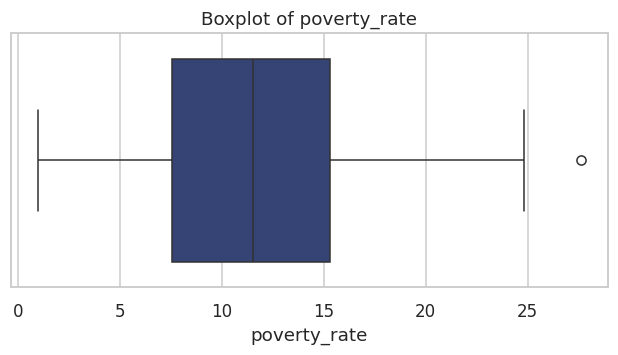

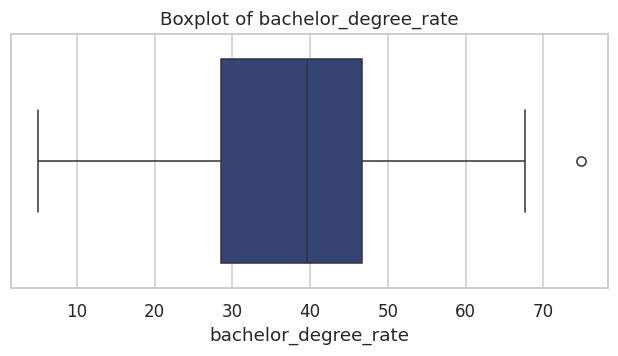

In [ ]:
for col in ["median_income", "internet_access_rate", "poverty_rate", "bachelor_degree_rate"]:
    if col in clean_data.columns:
        plt.figure(figsize=(7, 3))
        sns.boxplot(x=clean_data[col])
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.show()

## 13. Compare Groups

If the dataset includes a county column, summarize internet access by county.

In [ ]:
if "county" in clean_data.columns:
    county_summary = (
        clean_data.groupby("county", as_index=False)
        .agg(
            avg_internet_access=("internet_access_rate", "mean"),
            avg_income=("median_income", "mean"),
            avg_poverty=("poverty_rate", "mean"),
            records=("internet_access_rate", "count")
        )
        .sort_values("avg_internet_access", ascending=False)
    )
    display(county_summary)
else:
    print("No county column found in this dataset.")

,county,avg_internet_access,avg_income,avg_poverty,records
10,Passaic,77.19,"85,766.67",11.33,15
5,Mercer,74.23,"80,257.27",10.86,11
11,Union,73.26,"77,111.00",9.01,8
4,Hudson,73.09,"85,544.65",13.51,17
1,Burlington,72.87,"89,412.78",13.40,9
8,Morris,72.64,"81,394.89",15.03,18
7,Monmouth,72.47,"81,164.13",11.50,15
6,Middlesex,72.45,"82,600.09",9.66,11
9,Ocean,72.41,"75,666.70",10.93,10
0,Bergen,71.86,"73,577.79",10.21,14


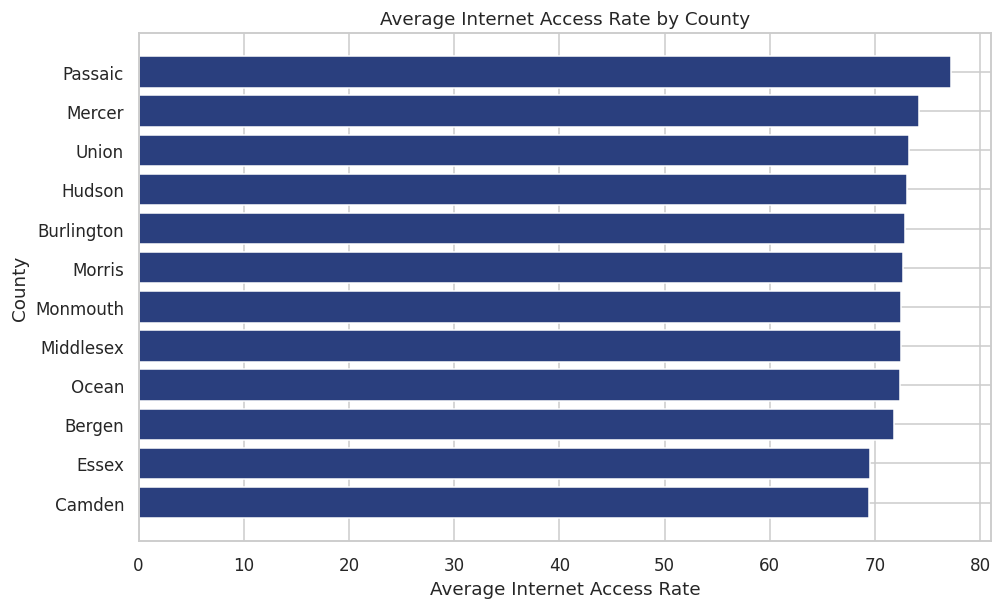

In [ ]:
if "county" in clean_data.columns:
    plt.figure(figsize=(10, 6))
    plot_data = county_summary.sort_values("avg_internet_access", ascending=True)

    plt.barh(plot_data["county"], plot_data["avg_internet_access"])
    plt.title("Average Internet Access Rate by County")
    plt.xlabel("Average Internet Access Rate")
    plt.ylabel("County")
    plt.show()
else:
    print("No county column found in this dataset.")

## 14. Optional: Correlation Check

Correlation measures the strength and direction of a linear relationship between numerical variables.

Values closer to `1` indicate a stronger positive relationship. Values closer to `-1` indicate a stronger negative relationship. Values near `0` indicate weak or no linear relationship.

In [ ]:
corr_cols = [
    "median_income",
    "internet_access_rate",
    "broadband_subscription_rate",
    "bachelor_degree_rate",
    "poverty_rate",
    "unemployment_rate"
]

corr_matrix = clean_data[corr_cols].corr(numeric_only=True)
corr_matrix

,median_income,internet_access_rate,broadband_subscription_rate,bachelor_degree_rate,poverty_rate,unemployment_rate
median_income,1.00,0.66,0.67,0.14,0.11,-0.05
internet_access_rate,0.66,1.00,0.90,0.41,-0.10,-0.05
broadband_subscription_rate,0.67,0.90,1.00,0.42,-0.06,-0.06
bachelor_degree_rate,0.14,0.41,0.42,1.00,0.06,-0.09
poverty_rate,0.11,-0.10,-0.06,0.06,1.00,0.00
unemployment_rate,-0.05,-0.05,-0.06,-0.09,0.00,1.00


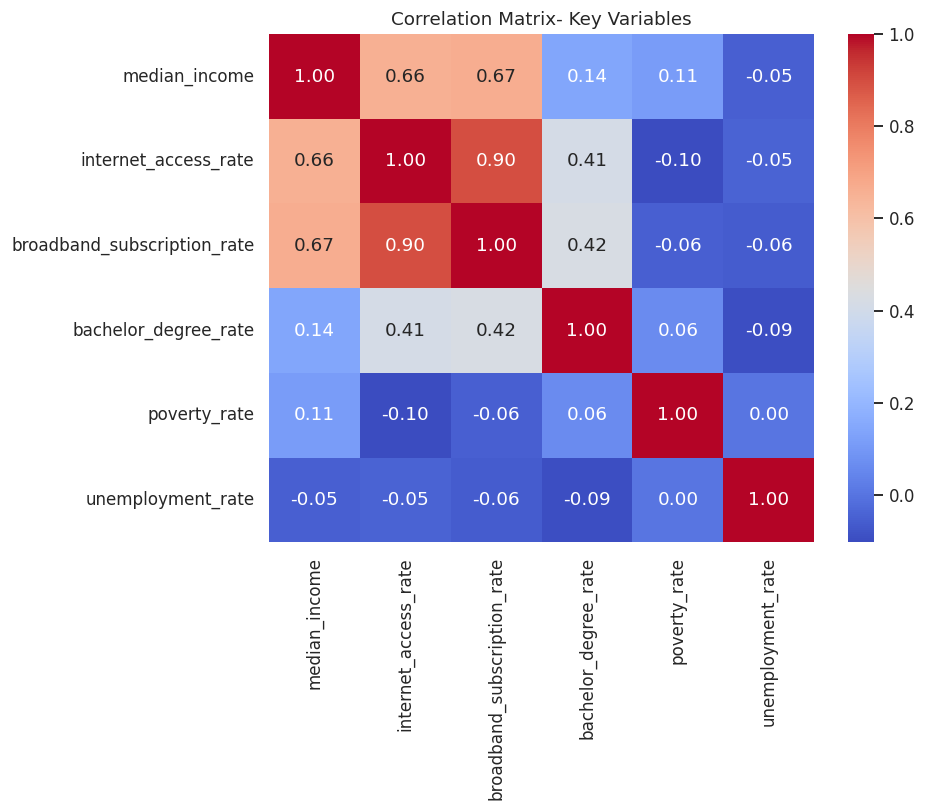

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix- Key Variables")
plt.show()

## 15. Generate Insights

An insight is not just an observation — it connects a pattern to a possible meaning.

Use this structure for each insight you want to record:

> **Pattern:** The data shows that...  
> **Interpretation:** This may suggest...  
> **Limitation:** However, we would need...

---

**Starter prompts to help you:**
- Look at the scatterplot: what direction does the relationship between income and internet access run?
- Look at the county bar chart: which county has the lowest average access? What might explain that?
- Look at the correlation matrix: which variable has the strongest positive relationship with internet access?

**Write at least two insights below.**

In [ ]:
# ============================================================
# YOUR INSIGHTS
# ============================================================
# Replace the placeholder text with your own observations.

insight_1 = """
Pattern:       [The data shows that...]
Interpretation:[This may suggest...]
Limitation:    [However, we would need...]
"""

insight_2 = """
Pattern:       [The data shows that...]
Interpretation:[This may suggest...]
Limitation:    [However, we would need...]
"""

print("--- Insight 1 ---")
print(insight_1)
print("--- Insight 2 ---")
print(insight_2)

--- Insight 1 ---

Pattern:       [The data shows that...]
Interpretation:[This may suggest...]
Limitation:    [However, we would need...]

--- Insight 2 ---

Pattern:       [The data shows that...]
Interpretation:[This may suggest...]
Limitation:    [However, we would need...]



## 16. Save the Cleaned Dataset

The cleaned dataset is the output of today's workflow. Saving it in a consistent, documented format means the next analyst — or the next workshop — can pick up exactly where you left off.

**In Workshop 2**, we will load this file and use it to build a regression model that predicts internet access rates from income and other factors. The cleaning work you did today directly affects the quality of those models.

Good data cleaning is not just housekeeping — it is what makes downstream analysis trustworthy.

In [ ]:
clean_data.to_csv("digital_inequity_nj_cleaned_for_workshop2.csv", index=False)
print("Saved: digital_inequity_nj_cleaned_for_workshop2.csv")

try:
    from google.colab import files
    files.download("digital_inequity_nj_cleaned_for_workshop2.csv")
except Exception:
    print("Download available when running in Google Colab.")

Saved: digital_inequity_nj_cleaned_for_workshop2.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 17. Exit Ticket ⏱ 5 min

Before you finish, write a brief answer to each question. There are no right or wrong answers — these help you consolidate what you did.

1. **What is one data quality issue you found in this dataset?**

2. **What cleaning decision did you make, and why?**

3. **What is one pattern you noticed in the data?**

4. **What question would you investigate next if you had more time?**

In [ ]:
# ============================================================
# EXIT TICKET — type your answers here if preferred
# ============================================================

q1_data_quality_issue = """

"""

q2_cleaning_decision = """

"""

q3_pattern = """

"""

q4_next_question = """

"""

## Suggested Extension

After the workshop, participants can:

- Compare results before and after cleaning.
- Add one more explanatory variable.
- Improve one visualization.
- Write a short paragraph summarizing the findings.
- Prepare for Workshop 2 by thinking about what variable might explain internet access differences.

---

## Learning Objectives — Check-In

At the start of this workshop, we set six goals. Review them and reflect on which you feel confident about.

1. ✅ Load and inspect a real-world-style dataset.
2. ✅ Identify common data quality issues: missing values, outliers, duplicates, and special placeholder codes.
3. ✅ Clean a dataset in a transparent and reproducible way.
4. ✅ Conduct exploratory data analysis (EDA).
5. ✅ Create simple visualizations.
6. ✅ Translate patterns into plain-language insights.

If any of these feel uncertain, the Suggested Extension section above gives you a way to continue practising on your own before Workshop 2.